<a href="https://colab.research.google.com/github/Decoding-Data-Science/CommunityWorkshops/blob/main/langchain_create_agent_sql_agent_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LangChain `create_agent` SQL Agent — Google Colab Version

This notebook is a Colab-ready version of the **Fast Agent - Build a SQL Agent fast** exercise.

## What this notebook does

- Loads your OpenAI API key from **Google Colab Secrets**
- Downloads the **Chinook SQLite database** automatically
- Creates a LangChain SQL tool called `execute_sql`
- Injects the database connection through LangChain runtime context
- Builds an agent using `create_agent`
- Lets the agent answer SQL questions by writing and executing SQLite queries

## Use case

You will ask questions such as:

- Which table has the largest number of entries?
- Which genre on average has the longest tracks?
- Please list all of the tables.

The agent will use a SQL tool to inspect and query the database.


## Step 0: Install Required Libraries

The original notebook uses LangChain, LangGraph runtime context, LangChain Community SQL utilities, and OpenAI integration.

The original notebook does not include exact pinned package versions inside the `.ipynb` file, so this Colab version installs the latest compatible versions and prints the installed versions in the next cell.

After running this cell, if Colab asks you to restart the runtime, restart it and continue from the next cell.


In [ ]:
!pip -q install -U \
    langchain \
    langchain-openai \
    langchain-community \
    langchain-core \
    langgraph \
    python-dotenv \
    requests


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.1/114.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.3/234.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 858.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==

## Step 1: Check Installed Versions

This replaces the original notebook's `doublecheck_pkgs()` helper, which depends on local course files that are not available in Google Colab.


In [ ]:
import importlib.metadata as metadata

packages = [
    "langchain",
    "langchain-openai",
    "langchain-community",
    "langchain-core",
    "langgraph",
    "python-dotenv",
    "requests",
]

print("Installed package versions:\n")
for package in packages:
    try:
        print(f"{package}: {metadata.version(package)}")
    except metadata.PackageNotFoundError:
        print(f"{package}: not installed")


Installed package versions:

langchain: 1.3.0
langchain-openai: 1.2.1
langchain-community: 0.4.1
langchain-core: 1.4.0
langgraph: 1.2.0
python-dotenv: 1.2.2
requests: 2.34.0


## Step 2: Load OpenAI API Key from Colab Secrets

In Google Colab:

1. Click the **key icon** on the left sidebar.
2. Add this secret exactly:

```text
OPENAI_API_KEY
```

3. Enable **Notebook access** for the secret.

This notebook does not hard-code your OpenAI key.


In [ ]:
import os
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get("openai")

## Step 3: Download the Chinook SQLite Database

The original notebook expects a local file named `Chinook.db`.

In Colab, we download the Chinook SQLite database automatically and save it as `Chinook.db`.


In [ ]:
from pathlib import Path
import requests

CHINOOK_URL = "https://github.com/lerocha/chinook-database/raw/master/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite"
DB_PATH = Path("Chinook.db")

if not DB_PATH.exists():
    response = requests.get(CHINOOK_URL, timeout=60)
    response.raise_for_status()
    DB_PATH.write_bytes(response.content)

if DB_PATH.stat().st_size < 100_000:
    raise ValueError("Downloaded database file looks too small. Please check the download URL.")

print(f"Database ready: {DB_PATH.resolve()}")
print(f"File size: {DB_PATH.stat().st_size / 1024 / 1024:.2f} MB")


Database ready: /content/Chinook.db
File size: 0.96 MB


## Step 4: Connect LangChain to the SQLite Database

This follows the same structure as your original notebook:

```python
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")
```


In [ ]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

print("Database connected successfully.")
print("Usable tables:")
print(db.get_usable_table_names())


Database connected successfully.
Usable tables:
['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']


## Step 5: Define Runtime Context

Runtime context allows us to inject the database connection into the agent at execution time.

This keeps the SQL tool reusable and avoids hard-coding database connections inside the tool.


In [ ]:
from dataclasses import dataclass


@dataclass
class RuntimeContext:
    db: SQLDatabase


## Step 6: Create a Safe SQL Execution Tool

The original notebook creates an `execute_sql` tool.

This Colab version keeps the same concept but adds a simple read-only safety check. The tool only allows:

- `SELECT` queries
- `WITH` queries
- `PRAGMA` read-only inspection queries

For production use, you should add stronger SQL validation, table permissions, logging, and query limits.


In [ ]:
import re
from langchain.tools import tool, ToolRuntime


DISALLOWED_SQL_PATTERN = re.compile(
    r"\b(INSERT|UPDATE|DELETE|ALTER|DROP|CREATE|REPLACE|TRUNCATE|ATTACH|DETACH|VACUUM)\b",
    re.IGNORECASE,
)


def is_read_only_sql(query: str) -> bool:
    """Basic read-only guard for demo purposes."""
    cleaned = query.strip().rstrip(";").strip()
    if DISALLOWED_SQL_PATTERN.search(cleaned):
        return False
    return cleaned.upper().startswith(("SELECT", "WITH", "PRAGMA"))


@tool
def execute_sql(query: str, runtime: ToolRuntime[RuntimeContext]) -> str:
    """Execute a read-only SQLite query and return results.

    Use this tool to inspect and analyze the Chinook SQLite database.
    Only read-only SQL queries are allowed.
    """
    if not is_read_only_sql(query):
        return (
            "Error: Only read-only SELECT, WITH, or PRAGMA queries are allowed. "
            "Do not use INSERT, UPDATE, DELETE, ALTER, DROP, CREATE, REPLACE, TRUNCATE, ATTACH, DETACH, or VACUUM."
        )

    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as error:
        return f"Error: {error}"


## Step 7: Add the System Prompt

This prompt guides the agent to behave like a careful SQLite analyst.


In [ ]:
SYSTEM_PROMPT = """
You are a careful SQLite analyst working with the Chinook database.

Rules:
- Think step-by-step before choosing a SQL query.
- When you need data, call the tool execute_sql with one read-only SQLite query.
- Prefer SELECT queries. You may use PRAGMA only for schema inspection.
- Read-only only. Never use INSERT, UPDATE, DELETE, ALTER, DROP, CREATE, REPLACE, TRUNCATE, ATTACH, DETACH, or VACUUM.
- Limit result previews to 5 rows unless the user explicitly asks otherwise.
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT * unless exploring the table structure.
- When answering, summarize the result clearly in plain English.
"""


## Step 8: Create the Agent

This keeps the original structure:

```python
from langchain.agents import create_agent

agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
)
```

If your OpenAI account does not have access to `gpt-5-mini`, change `MODEL_NAME` to a model available in your account.


In [ ]:
from langchain.agents import create_agent


MODEL_NAME = "openai:gpt-5-mini"

agent = create_agent(
    model=MODEL_NAME,
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
)

print("SQL agent created successfully.")


SQL agent created successfully.


## Optional: Display the Agent Graph

This is useful for teaching the ReAct / agent loop visually.

If graph rendering fails in Colab, you can skip this cell. The agent will still work.


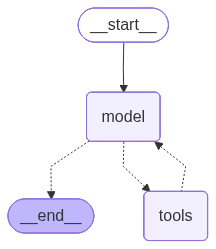

In [ ]:
from IPython.display import Image, display

try:
    display(Image(agent.get_graph(xray=True).draw_mermaid_png()))
except Exception as error:
    print("Graph rendering skipped:", error)


## Helper Function: Ask the SQL Agent

This function streams the agent steps and prints each message.


In [ ]:
def ask_sql_agent(question: str):
    """Ask the SQL agent a question and stream the response."""
    print(f"Question: {question}\n")

    for step in agent.stream(
        {
            "messages": [
                {
                    "role": "user",
                    "content": question,
                }
            ]
        },
        context=RuntimeContext(db=db),
        stream_mode="values",
    ):
        step["messages"][-1].pretty_print()


## Query 1: Which Table Has the Largest Number of Entries?

This is the same exercise from your original notebook.

The agent may first inspect the database schema, then count rows across tables.


In [ ]:
ask_sql_agent("Which table has the largest number of entries?")


Question: Which table has the largest number of entries?

================================ Human Message =================================

Which table has the largest number of entries?
================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_lE63zYkwi4f8hFpUakyaFMLT)
 Call ID: call_lE63zYkwi4f8hFpUakyaFMLT
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%' ORDER BY name;
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_WBx8SmcDXTtm4rQG2Ned5CSd)
 Call ID: call_WBx8SmcDXTtm4rQG2Ned5CSd
  Args:
    query: SELECT 'Album' AS table_name, COUNT(*) AS cnt FROM Album
UNI

In [ ]:
ask_sql_agent("which is the most famous artist by sales and tracks sold per year")

Question: which is the most famous artist by sales and tracks sold per year

================================ Human Message =================================

which is the most famous artist by sales and tracks sold per year
================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_vAt7s4sraHlXVLHCA3vxOEwh)
 Call ID: call_vAt7s4sraHlXVLHCA3vxOEwh
  Args:
    query: WITH artist_year AS (
 SELECT
  a.ArtistId,
  a.Name AS Artist,
  CAST(strftime('%Y', i.InvoiceDate) AS INTEGER) AS Year,
  SUM(ii.UnitPrice * ii.Quantity) AS Revenue,
  SUM(ii.Quantity) AS TracksSold
 FROM artists a
 JOIN albums al ON al.ArtistId = a.ArtistId
 JOIN tracks t ON t.AlbumId = al.AlbumId
 JOIN invoice_items ii ON ii.TrackId = t.TrackId
 JOIN invoices i ON i.InvoiceId = ii.InvoiceId
 GROUP BY Year, a.ArtistId
)
SELECT Year, Artist, ROUND(Revenue,2) AS Revenue, TracksSold,
 CASE WHEN sales_rank = 1 THEN 1 ELSE 0 END AS TopBySales,
 CASE WHEN tracks_rank = 1 TH

## Query 2: Which Genre Has the Longest Tracks on Average?

This is another exercise from your original notebook.


In [ ]:
ask_sql_agent("Which genre on average has the longest tracks?")


Question: Which genre on average has the longest tracks?

================================ Human Message =================================

Which genre on average has the longest tracks?
================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_FRTQsnDcQ8OMyyQsUPklrNpG)
 Call ID: call_FRTQsnDcQ8OMyyQsUPklrNpG
  Args:
    query: SELECT g.Name AS Genre, AVG(t.Milliseconds) AS avg_ms, AVG(t.Milliseconds)/1000.0 AS avg_seconds, AVG(t.Milliseconds)/60000.0 AS avg_minutes
FROM Genre g JOIN Track t ON g.GenreId = t.GenreId
GROUP BY g.Name
ORDER BY avg_ms DESC
LIMIT 1;
================================= Tool Message =================================
Name: execute_sql

[('Sci Fi & Fantasy', 2911783.0384615385, 2911.7830384615386, 48.52971730769231)]
================================== Ai Message ==================================
Tool Calls:
  execute_sql (call_CKRY4e9wJTJId97aJdoEfuo2)
 Call ID: call_CKRY4e9wJTJId97aJdoEfuo2
  Args:
    quer

## Query 3: List All Tables

This checks whether the agent can inspect the SQLite database structure.


In [ ]:
ask_sql_agent("Please list all of the tables.")


## Query 4: Try Your Own Question

Edit the question below and run the cell.


In [ ]:
my_question = "Who are the top 5 customers by total invoice amount?"

ask_sql_agent(my_question)


In [ ]:
db.run("SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name LIMIT 20;")


"[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]"

In [ ]:
# ============================================================
# FINAL PART: SQL Agent with Modern LangChain Memory + Chat Loop
# ============================================================

from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import display, Markdown


# ------------------------------------------------------------
# 1. Choose model
# ------------------------------------------------------------
# Use the latest model available in your OpenAI account.
# LangChain docs currently show GPT-5.4 in the create_agent memory examples.
# If your account has GPT-5.5 enabled, you can replace this with:
# MODEL_NAME = "openai:gpt-5.5"

MODEL_NAME = "openai:gpt-5.4"


# ------------------------------------------------------------
# 2. Create modern LangChain memory
# ------------------------------------------------------------
# This stores short-term conversation memory for each thread_id.
# For demo / notebook usage, InMemorySaver is enough.
# For production, use a persistent checkpointer such as Postgres.

checkpointer = InMemorySaver()


# ------------------------------------------------------------
# 3. Create SQL agent with memory
# ------------------------------------------------------------
# This assumes these already exist earlier in your notebook:
# - execute_sql
# - SYSTEM_PROMPT
# - RuntimeContext
# - db

sql_agent_with_memory = create_agent(
    model=MODEL_NAME,
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
    checkpointer=checkpointer,
)


# ------------------------------------------------------------
# 4. Fixed thread ID for follow-up conversation
# ------------------------------------------------------------
# Same thread_id = same memory.
# New thread_id = fresh conversation.

THREAD_ID = "chinook-sql-demo-thread-1"


# ------------------------------------------------------------
# 5. Function to ask SQL agent one question
# ------------------------------------------------------------

def ask_sql_agent_with_memory(user_input: str, thread_id: str = THREAD_ID) -> str:
    """
    Ask the SQL agent a question using modern LangChain create_agent + memory.

    Memory works because:
    - the agent has a checkpointer
    - the same thread_id is passed every time
    """

    result = sql_agent_with_memory.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": user_input,
                }
            ]
        },
        config={
            "configurable": {
                "thread_id": thread_id
            }
        },
        context=RuntimeContext(db=db),
    )

    output_message = result["messages"][-1].content

    display(Markdown(f"""
### User Input

{user_input}

### Agent Output

{output_message}
"""))

    return output_message


# ------------------------------------------------------------
# 6. Continuous chat loop
# ------------------------------------------------------------

def run_sql_agent_chat_loop(thread_id: str = THREAD_ID):
    """
    Run a simple notebook-based chat loop.

    The user can keep asking follow-up questions.
    The agent remembers previous turns because the same thread_id is reused.

    Type:
    - exit
    - quit
    - q

    to stop the chat.
    """

    print("SQL Agent Chat Started")
    print("Ask questions about the Chinook database.")
    print("Type 'exit', 'quit', or 'q' to stop.")
    print("-" * 80)

    while True:
        user_input = input("\nYou: ").strip()

        if user_input.lower() in ["exit", "quit", "q"]:
            print("\nChat ended.")
            break

        if not user_input:
            print("Please enter a question.")
            continue

        try:
            output_message = ask_sql_agent_with_memory(
                user_input=user_input,
                thread_id=thread_id
            )

            print("\nAssistant:")
            print(output_message)
            print("-" * 80)

        except Exception as e:
            print("\nSomething went wrong:")
            print(e)
            print("-" * 80)


# ------------------------------------------------------------
# 7. Start the chat loop
# ------------------------------------------------------------

run_sql_agent_chat_loop()

SQL Agent Chat Started
Ask questions about the Chinook database.
Type 'exit', 'quit', or 'q' to stop.
--------------------------------------------------------------------------------

You: which is the most famous artist by sales sold per year



### User Input

which is the most famous artist by sales sold per year

### Agent Output

The top artist by average sales per year in the Chinook database is **Iron Maiden**.

Top 5 artists by sales per year:
1. **Iron Maiden** — total sales **138.60**, across **5** years, averaging **27.72/year**
2. **U2** — total sales **105.93**, across **4** years, averaging **26.48/year**
3. **Lost** — total sales **81.59**, across **4** years, averaging **20.40/year**
4. **Metallica** — total sales **90.09**, across **5** years, averaging **18.02/year**
5. **Led Zeppelin** — total sales **86.13**, across **5** years, averaging **17.23/year**

If you want, I can also show:
- the **most famous artist by total sales** instead of per year, or
- a **year-by-year sales breakdown** for the top artist.



Assistant:
The top artist by average sales per year in the Chinook database is **Iron Maiden**.

Top 5 artists by sales per year:
1. **Iron Maiden** — total sales **138.60**, across **5** years, averaging **27.72/year**
2. **U2** — total sales **105.93**, across **4** years, averaging **26.48/year**
3. **Lost** — total sales **81.59**, across **4** years, averaging **20.40/year**
4. **Metallica** — total sales **90.09**, across **5** years, averaging **18.02/year**
5. **Led Zeppelin** — total sales **86.13**, across **5** years, averaging **17.23/year**

If you want, I can also show:
- the **most famous artist by total sales** instead of per year, or
- a **year-by-year sales breakdown** for the top artist.
--------------------------------------------------------------------------------

You: add tracks as well and dispaly in table



### User Input

add tracks as well and dispaly in table

### Agent Output

Here’s the table with **tracks included**:

| Rank | Artist        | Tracks | Total Sales | Active Years | Sales per Year |
|------|---------------|--------|-------------|--------------|----------------|
| 1 | Iron Maiden | 123 | 138.60 | 5 | 27.72 |
| 2 | U2 | 91 | 105.93 | 4 | 26.48 |
| 3 | Lost | 40 | 81.59 | 4 | 20.40 |
| 4 | Metallica | 79 | 90.09 | 5 | 18.02 |
| 5 | Led Zeppelin | 77 | 86.13 | 5 | 17.23 |

So, **Iron Maiden** is still the top artist by **sales per year**, and they have **123 tracks** in the database.

If you want, I can also add **total units sold** alongside revenue.



Assistant:
Here’s the table with **tracks included**:

| Rank | Artist        | Tracks | Total Sales | Active Years | Sales per Year |
|------|---------------|--------|-------------|--------------|----------------|
| 1 | Iron Maiden | 123 | 138.60 | 5 | 27.72 |
| 2 | U2 | 91 | 105.93 | 4 | 26.48 |
| 3 | Lost | 40 | 81.59 | 4 | 20.40 |
| 4 | Metallica | 79 | 90.09 | 5 | 18.02 |
| 5 | Led Zeppelin | 77 | 86.13 | 5 | 17.23 |

So, **Iron Maiden** is still the top artist by **sales per year**, and they have **123 tracks** in the database.

If you want, I can also add **total units sold** alongside revenue.
--------------------------------------------------------------------------------

You: give the sql code for this 



### User Input

give the sql code for this

### Agent Output

```sql
SELECT
    ar.Name AS artist_name,
    COUNT(DISTINCT t.TrackId) AS track_count,
    ROUND(SUM(ii.Quantity * ii.UnitPrice), 2) AS total_sales,
    COUNT(DISTINCT strftime('%Y', i.InvoiceDate)) AS active_years,
    ROUND(
        SUM(ii.Quantity * ii.UnitPrice) /
        COUNT(DISTINCT strftime('%Y', i.InvoiceDate)),
        2
    ) AS sales_per_year
FROM Artist ar
JOIN Album al
    ON al.ArtistId = ar.ArtistId
JOIN Track t
    ON t.AlbumId = al.AlbumId
JOIN InvoiceLine ii
    ON ii.TrackId = t.TrackId
JOIN Invoice i
    ON i.InvoiceId = ii.InvoiceId
GROUP BY ar.ArtistId, ar.Name
ORDER BY sales_per_year DESC
LIMIT 5;
```



Assistant:
```sql
SELECT
    ar.Name AS artist_name,
    COUNT(DISTINCT t.TrackId) AS track_count,
    ROUND(SUM(ii.Quantity * ii.UnitPrice), 2) AS total_sales,
    COUNT(DISTINCT strftime('%Y', i.InvoiceDate)) AS active_years,
    ROUND(
        SUM(ii.Quantity * ii.UnitPrice) /
        COUNT(DISTINCT strftime('%Y', i.InvoiceDate)),
        2
    ) AS sales_per_year
FROM Artist ar
JOIN Album al
    ON al.ArtistId = ar.ArtistId
JOIN Track t
    ON t.AlbumId = al.AlbumId
JOIN InvoiceLine ii
    ON ii.TrackId = t.TrackId
JOIN Invoice i
    ON i.InvoiceId = ii.InvoiceId
GROUP BY ar.ArtistId, ar.Name
ORDER BY sales_per_year DESC
LIMIT 5;
```
--------------------------------------------------------------------------------

You: q

Chat ended.


In [ ]:
# ============================================================
# FINAL PART: SQL Agent with Modern LangChain Memory + Gradio 6 UI
# Messages-only version for Gradio 6
# ============================================================

from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
import gradio as gr
from uuid import uuid4


# ------------------------------------------------------------
# 1. Choose model
# ------------------------------------------------------------
# Use the latest model available in your OpenAI account.
# If your account has GPT-5.5 enabled, you can replace this with:
# MODEL_NAME = "openai:gpt-5.5"

MODEL_NAME = "openai:gpt-5.4"


# ------------------------------------------------------------
# 2. Create modern LangChain memory
# ------------------------------------------------------------
# This stores short-term conversation memory for each thread_id.
# For demo / notebook usage, InMemorySaver is enough.
# For production, use a persistent checkpointer such as Postgres.

checkpointer = InMemorySaver()


# ------------------------------------------------------------
# 3. Create SQL agent with memory
# ------------------------------------------------------------
# This assumes these already exist earlier in your notebook:
# - execute_sql
# - SYSTEM_PROMPT
# - RuntimeContext
# - db

sql_agent_with_memory = create_agent(
    model=MODEL_NAME,
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
    checkpointer=checkpointer,
)


# ------------------------------------------------------------
# 4. Helper: safely convert LangChain message content to text
# ------------------------------------------------------------

def content_to_text(content):
    """
    LangChain message content can sometimes be:
    - a plain string
    - a list of content blocks
    - another object

    This helper converts it safely into displayable text for Gradio.
    """

    if isinstance(content, str):
        return content

    if isinstance(content, list):
        text_parts = []

        for item in content:
            if isinstance(item, dict):
                if "text" in item:
                    text_parts.append(item["text"])
                elif "content" in item:
                    text_parts.append(str(item["content"]))
                else:
                    text_parts.append(str(item))
            else:
                text_parts.append(str(item))

        return "\n".join(text_parts)

    return str(content)


# ------------------------------------------------------------
# 5. Helper: create a fresh thread_id
# ------------------------------------------------------------

def create_thread_id():
    """
    Each Gradio browser session gets its own thread_id.

    Same thread_id = same LangGraph memory.
    New thread_id = fresh conversation.
    """

    return f"chinook-sql-demo-{uuid4()}"


# ------------------------------------------------------------
# 6. Helper: normalize Gradio history into messages format
# ------------------------------------------------------------

def normalize_history_to_messages(history):
    """
    Gradio 6 expects messages format:
    [
        {"role": "user", "content": "..."},
        {"role": "assistant", "content": "..."}
    ]

    This helper protects the app if history comes back as:
    - None
    - already messages
    - old tuple pairs
    """

    if history is None:
        return []

    normalized = []

    for item in history:
        # Already in messages format
        if isinstance(item, dict) and "role" in item and "content" in item:
            normalized.append(
                {
                    "role": item["role"],
                    "content": content_to_text(item["content"]),
                }
            )

        # Old tuple format: (user, assistant)
        elif isinstance(item, (list, tuple)) and len(item) == 2:
            user_text, assistant_text = item

            if user_text:
                normalized.append(
                    {
                        "role": "user",
                        "content": content_to_text(user_text),
                    }
                )

            if assistant_text:
                normalized.append(
                    {
                        "role": "assistant",
                        "content": content_to_text(assistant_text),
                    }
                )

    return normalized


# ------------------------------------------------------------
# 7. Gradio chat function
# ------------------------------------------------------------

def chat_with_sql_agent(message, history, thread_id):
    """
    Handles one user message from Gradio.

    This version always returns Gradio 6 messages format:
    [
        {"role": "user", "content": "..."},
        {"role": "assistant", "content": "..."}
    ]

    LangGraph memory is controlled separately by thread_id.
    """

    history = normalize_history_to_messages(history)

    if not thread_id:
        thread_id = create_thread_id()

    if not message or not message.strip():
        return history, "", thread_id

    user_message = message.strip()

    try:
        result = sql_agent_with_memory.invoke(
            {
                "messages": [
                    {
                        "role": "user",
                        "content": user_message,
                    }
                ]
            },
            config={
                "configurable": {
                    "thread_id": thread_id
                }
            },
            context=RuntimeContext(db=db),
        )

        assistant_message = content_to_text(result["messages"][-1].content)

    except Exception as e:
        assistant_message = f"""
Something went wrong while running the SQL agent.

Error:

```text
{str(e)}
```
"""

    updated_history = history + [
        {
            "role": "user",
            "content": user_message,
        },
        {
            "role": "assistant",
            "content": assistant_message,
        },
    ]

    return updated_history, "", thread_id


# ------------------------------------------------------------
# 8. Reset conversation and memory
# ------------------------------------------------------------

def reset_chat():
    """
    Clears the Gradio UI and starts a fresh LangGraph memory thread.
    """

    return [], create_thread_id()


# ------------------------------------------------------------
# 9. Build Gradio 6 app
# ------------------------------------------------------------
# Important:
# Do NOT use type="messages" if your Gradio throws:
# TypeError: Chatbot.__init__() got an unexpected keyword argument 'type'
#
# In your runtime, the Chatbot is already expecting messages format.

with gr.Blocks(title="DDS SQL Agent") as demo:

    thread_id_state = gr.State(value=create_thread_id())

    gr.Markdown(
        """
# SQL Agent with Memory

Ask questions about the Chinook database.

The agent remembers follow-up questions inside the same chat session.
"""
    )

    chatbot = gr.Chatbot(
        value=[],
        height=520,
        label="SQL Agent Chat",
    )

    with gr.Row():
        user_input = gr.Textbox(
            placeholder="Example: Which customer spent the most money?",
            label="Your question",
            scale=8,
        )

        submit_btn = gr.Button(
            "Ask",
            scale=1,
            variant="primary",
        )

    clear_btn = gr.Button("New Chat / Reset Memory")

    submit_btn.click(
        fn=chat_with_sql_agent,
        inputs=[user_input, chatbot, thread_id_state],
        outputs=[chatbot, user_input, thread_id_state],
    )

    user_input.submit(
        fn=chat_with_sql_agent,
        inputs=[user_input, chatbot, thread_id_state],
        outputs=[chatbot, user_input, thread_id_state],
    )

    clear_btn.click(
        fn=reset_chat,
        inputs=[],
        outputs=[chatbot, thread_id_state],
    )


# ------------------------------------------------------------
# 10. Launch Gradio app
# ------------------------------------------------------------
# For normal notebook / local use:
demo.queue().launch()

# For Google Colab, use this instead:
# demo.queue().launch(share=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9499f622f65552676e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Ask a question about the Chinook database: Total number of tables



### User Input

Total number of tables

### Agent Output

The Chinook database contains **11 tables**.



Final Output:
The Chinook database contains **11 tables**.


In [ ]:
from google.colab import files

files.download('Chinook.db')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>